### Exploratory analysis of how inequalities are reflected in Olympic Games over time

#### Short Notes

- The dataset goes from **1896 to 2016**
- This notebook studies how inequalities appear in Olympic history through three main angles:

1. **Gender inequalities**  
2. **Geopolitical inequalities and disruptions**  
3. **Evolution of disciplines and structural inequalities**  

In [120]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import plotly.express as px

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

In [121]:
data_path = Path("../../data/olympics.csv")
olympics = pd.read_csv(data_path)

#### Basic Details

In [122]:
print("Entries in Olympics Dataset:", olympics.shape[0])
print("Olympics Dataset Columns:", ", ".join(olympics.columns))
olympics.head()

Entries in Olympics Dataset: 271116
Olympics Dataset Columns: id, name, gender, age, height, weight, team, noc, country, population, year, season, city, sport, event, medal, gdp_per_capita


,id,name,gender,age,height,weight,team,noc,country,population,year,season,city,sport,event,medal,gdp_per_capita
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,China,1.164970e+09,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,367.822652
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,China,1.350695e+09,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,6405.057424
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,Denmark,NaN,1920,Summer,Antwerpen,Football,Football Men's Football,NaN,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,Denmark,NaN,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,NaN
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,Netherlands,1.476009e+07,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,17770.616238


In [123]:
print("Earliest Year:", olympics["year"].min())
print("Latest Year:", olympics["year"].max())
print("Number of Seasons:", olympics["season"].nunique())
print("Number of Sports:", olympics["sport"].nunique())
print("Number of Events:", olympics["event"].nunique())
print("Number of Countries:", olympics["country"].nunique())

Earliest Year: 1896
Latest Year: 2016
Number of Seasons: 2
Number of Sports: 66
Number of Events: 765
Number of Countries: 205


#### Basic Statistics: Gender

In [124]:
gender_time = olympics.groupby(["year", "gender"]).size().reset_index(name="count")

# Rename for readability in plots
gender_time["gender"] = gender_time["gender"].replace({"M": "Men", "F": "Women"})

# Create all possible combinations
all_years = sorted(gender_time["year"].unique())
all_genders = ["Men", "Women"]

full_index = pd.MultiIndex.from_product(
    [all_years, all_genders],
    names=["year", "gender"]
)

gender_time = (
    gender_time
    .set_index(["year", "gender"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

fig_gender = px.bar(
    gender_time,
    x="gender",
    y="count",
    color="gender",
    animation_frame="year",
    range_y=[0, gender_time["count"].max() + 500],
    title="The Path to Parity: Athlete Records Over Time by Gender",
    template="ggplot2",
    color_discrete_map={
        "Men": "#ADD8E6",
        "Women": "#FFB6C1"
    }
)

fig_gender.update_layout(
    xaxis_title="Gender",
    yaxis_title="Number of Athlete Records"
)

fig_gender.show()

In [125]:
gender_share = (
    olympics.groupby(["year", "gender"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"F": "Women", "M": "Men"})
)

gender_share["total"] = gender_share.sum(axis=1)
gender_share["women_share"] = 100 * gender_share["Women"] / gender_share["total"]

print("Women's Share of Athlete Records by Year:")
gender_share[["Women", "Men", "women_share"]].tail(15)

Women's Share of Athlete Records by Year:


gender,Women,Men,women_share
year,,,
1984,2983,8605,25.742147
1988,4223,10453,28.774871
1992,5178,11235,31.548163
1994,1105,2055,34.968354
1996,5008,8772,36.342525
1998,1384,2221,38.391123
2000,5431,8390,39.295275
2002,1582,2527,38.500852
2004,5546,7897,41.255672


#### Basic Statistics: Gender Inequality by Sport

In [126]:
sport_gender = (
    olympics.groupby(["sport", "gender"])
    .size()
    .unstack(fill_value=0)
    .rename(columns={"F": "Women", "M": "Men"})
)

sport_gender["total"] = sport_gender.sum(axis=1)
sport_gender["women_share"] = 100 * sport_gender["Women"] / sport_gender["total"]

sport_gender.sort_values("women_share").head(10)

gender,Women,Men,total,women_share
sport,,,,
Aeronautics,0,1,1,0.0
Baseball,0,894,894,0.0
Cricket,0,24,24,0.0
Basque Pelota,0,2,2,0.0
Jeu De Paume,0,11,11,0.0
Nordic Combined,0,1344,1344,0.0
Military Ski Patrol,0,24,24,0.0
Lacrosse,0,60,60,0.0
Tug-Of-War,0,170,170,0.0


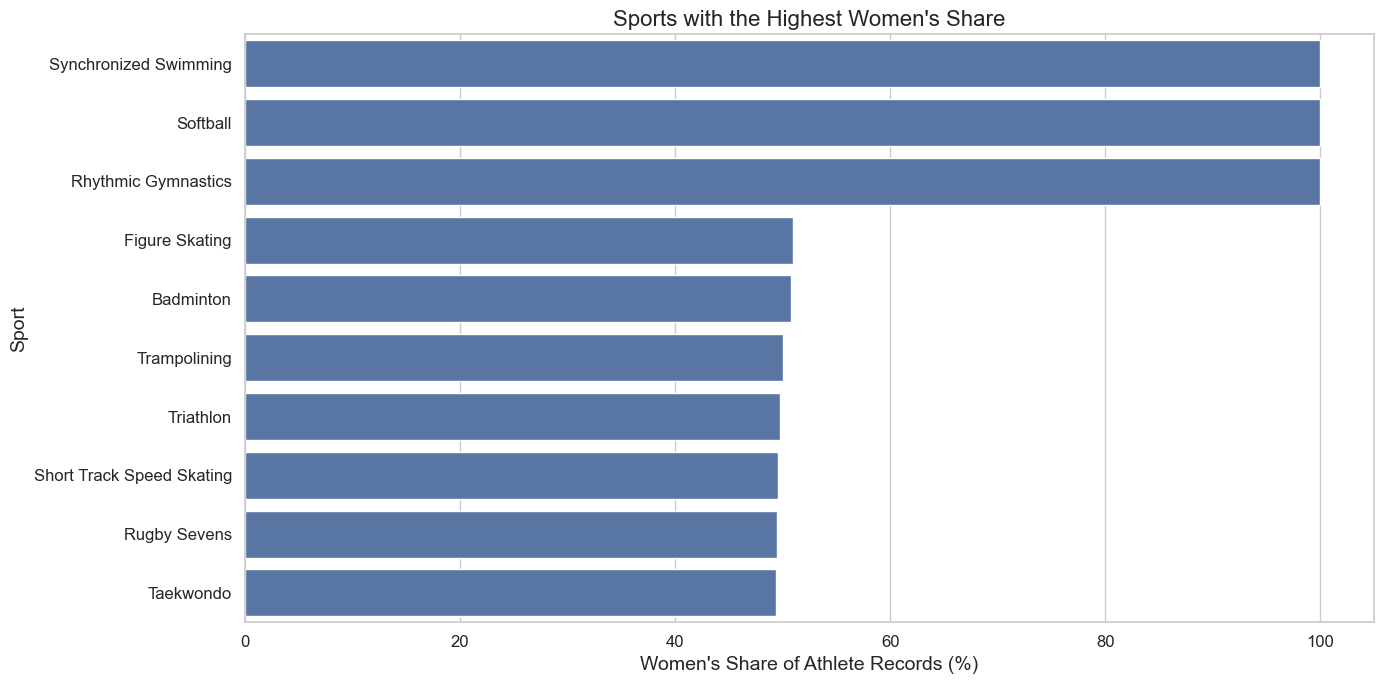

In [127]:
female_balanced = sport_gender.sort_values("women_share", ascending=False).head(10).reset_index()

plt.figure(figsize=(14, 7))
sns.barplot(data=female_balanced, x="women_share", y="sport")
plt.title("Sports with the Highest Women's Share", fontsize=16)
plt.xlabel("Women's Share of Athlete Records (%)", fontsize=14)
plt.ylabel("Sport", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

#### Basic Statistics: Sports and Events

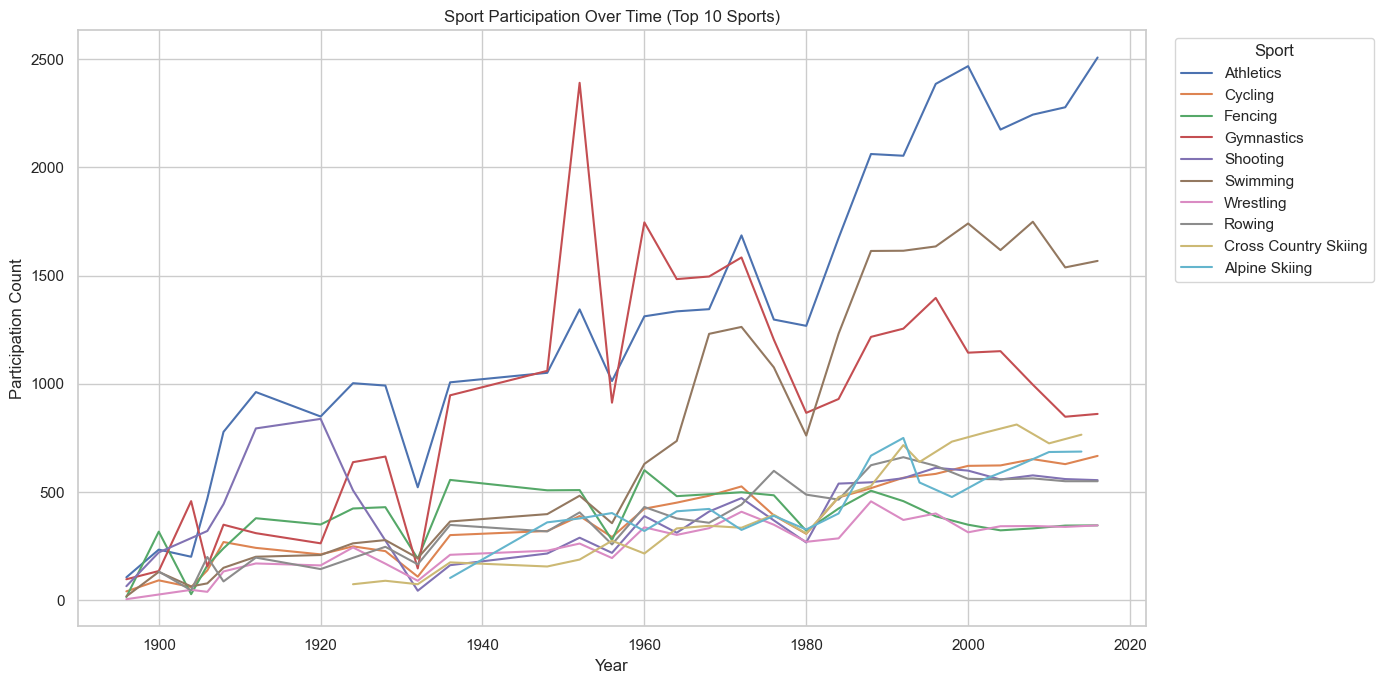

In [128]:
sport_year = (
    olympics.groupby(["year", "sport"])
    .size()
    .reset_index(name="participation_count")
)

# Top sports only
top_sports = (
    sport_year.groupby("sport")["participation_count"]
    .sum()
    .nlargest(10)
    .index
)

sport_year_top = sport_year[sport_year["sport"].isin(top_sports)]

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=sport_year_top,
    x="year",
    y="participation_count",
    hue="sport"
)
plt.title("Sport Participation Over Time (Top 10 Sports)")
plt.xlabel("Year")
plt.ylabel("Participation Count")
plt.legend(title="Sport", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

In [129]:
year_summary = (
    olympics.groupby("year")
    .agg(
        sports=("sport", "nunique"),
        events=("event", "nunique"),
        regions=("country", "nunique")
    )
    .reset_index()
)

year_summary.head()

,year,sports,events,regions
0,1896,9,43,12
1,1900,20,90,31
2,1904,18,95,14
3,1906,13,74,20
4,1908,24,109,22


#### Basic Statistics: Geopolitical Visibility

In [130]:
region_year = (
    olympics.groupby(["year", "country"])
    .size()
    .reset_index(name="count")
)

print("Countries with the most athlete records:")
olympics["country"].value_counts().head(15)

Countries with the most athlete records:


country
USA               18853
Germany           15883
France            12758
UK                12256
Russia            11692
Italy             10715
Canada             9734
Japan              8444
Sweden             8339
Australia          7724
Hungary            6607
Czech Republic     6431
Poland             6207
Switzerland        6150
Netherlands        5839
Name: count, dtype: int64

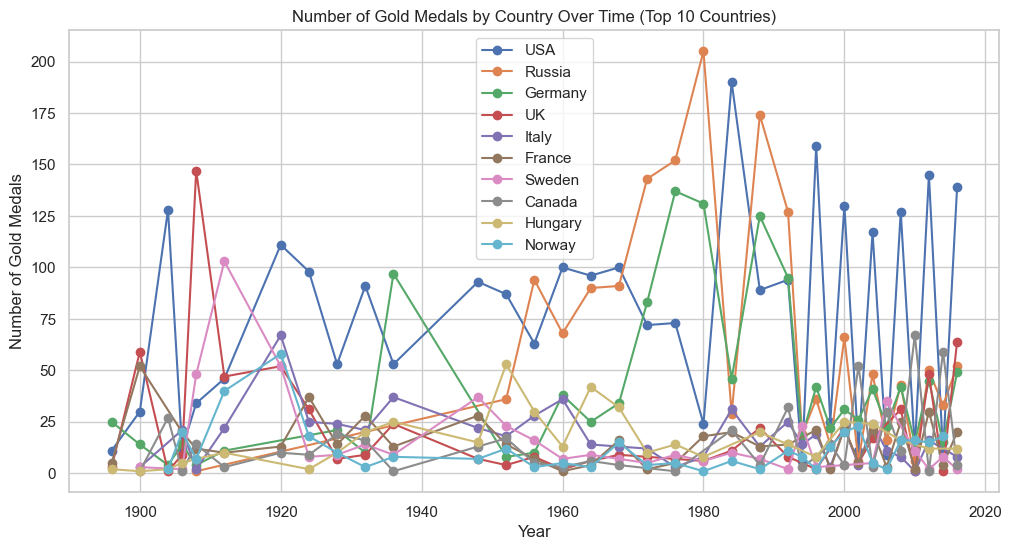

In [131]:
gold_medals = olympics[olympics["medal"] == "Gold"]

gold_year_region = (
    gold_medals
    .groupby(["year", "country"])
    .size()
    .reset_index(name="count")
)

top_regions = (
    gold_year_region
    .groupby("country")["count"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .index
)

gold_top = gold_year_region[gold_year_region["country"].isin(top_regions)]

plt.figure(figsize=(12, 6))

for country in top_regions:
    country_data = gold_top[gold_top["country"] == country]
    plt.plot(country_data["year"], country_data["count"], marker="o", label=country)

plt.title("Number of Gold Medals by Country Over Time (Top 10 Countries)")
plt.xlabel("Year")
plt.ylabel("Number of Gold Medals")
plt.legend()
plt.show()

In [132]:
fig = px.line(
    gold_top,
    x="year",
    y="count",
    color="country",
    title="Gold Medals by Country Over Time (Top 10 Countries)"
)

fig.show()

In [153]:
all_countries = set(olympics["country"].dropna().unique())
medal_countries = set(olympics.loc[olympics["medal"].notna(), "country"].dropna().unique())

never_medaled = sorted(all_countries - medal_countries)

never_medaled_df = (
    olympics[olympics["country"].isin(never_medaled)]
    .groupby("country")
    .agg(
        participations=("id", "count"),
        sports=("sport", "nunique")
    )
    .sort_values("participations", ascending=False)
    .reset_index()
)

print(f"Number of countries that never won a medal: {len(never_medaled_df)}")
never_medaled_df.head(20)

Number of countries that never won a medal: 69


,country,participations,sports
0,Angola,267,11
1,El Salvador,218,14
2,Honduras,189,13
3,San Marino,181,14
4,Andorra,169,12
5,Boliva,152,16
6,Bosnia and Herzegovina,134,15
7,Antigua,133,6
8,Nicaragua,129,10
9,Madagascar,119,9


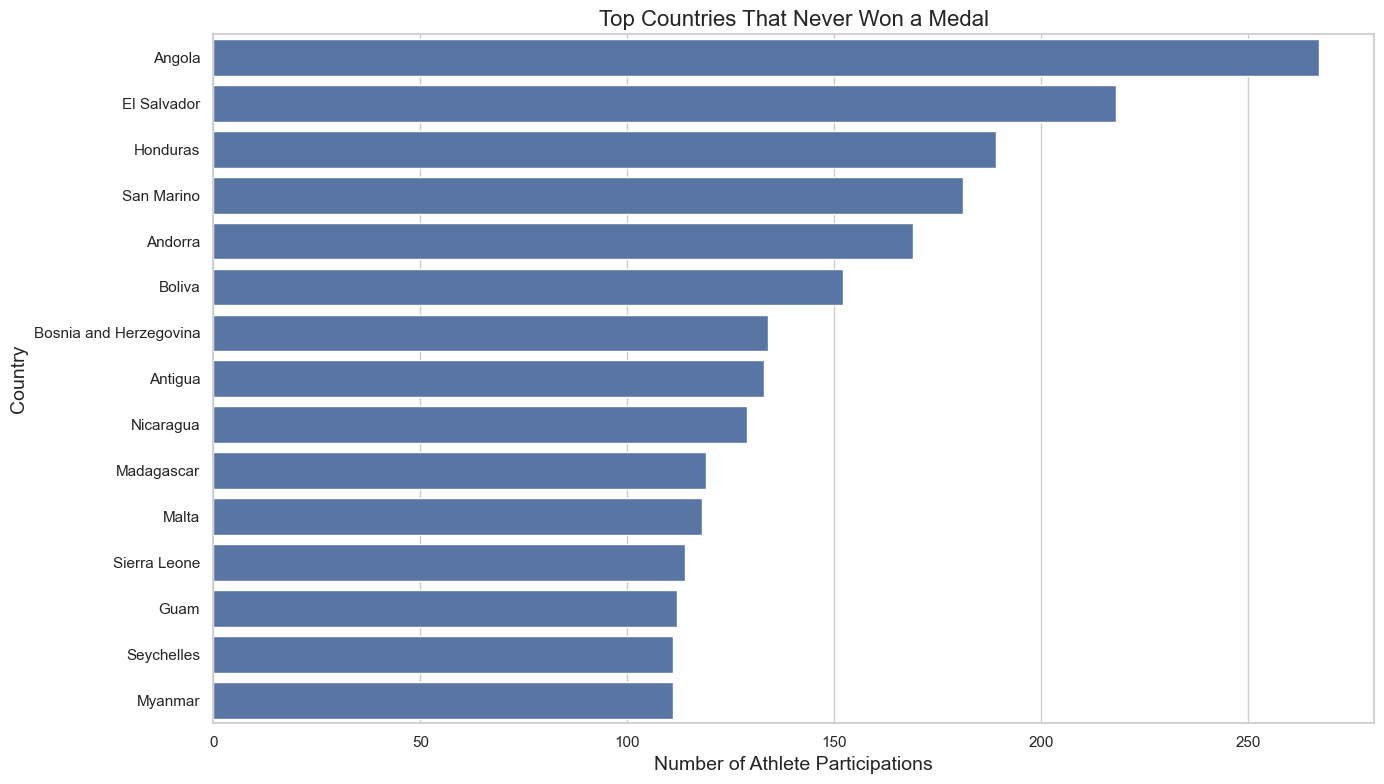

In [155]:
plt.figure(figsize=(14, 8))
sns.barplot(
    data=never_medaled_df.head(15),
    x="participations",
    y="country"
)
plt.title("Top Countries That Never Won a Medal", fontsize=16)
plt.xlabel("Number of Athlete Participations", fontsize=14)
plt.ylabel("Country", fontsize=14)
plt.tight_layout()
plt.show()

#### Basic Statistics: GDP

In [137]:
medals_df = olympics[
    olympics["medal"].notna() &
    olympics["gdp_per_capita"].notna() &
    olympics["population"].notna()
].copy()

country_medals = (
    medals_df.groupby(["country", "gdp_per_capita", "population"])
    .size()
    .reset_index(name="medal_count")
)

fig = px.scatter(
    country_medals,
    x="gdp_per_capita",
    y="medal_count",
    size="population",              # circle size based on population
    hover_name="country",
    title="GDP per Capita vs Medal Count",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "medal_count": "Total Medal Count",
        "population": "Population"
    },
    size_max=30                     # control max bubble size
)

fig.show()

In [138]:
medals_df = olympics[
    olympics["medal"].notna() &
    olympics["gdp_per_capita"].notna() &
    olympics["population"].notna()
].copy()

country_medals = (
    medals_df
    .groupby(["year", "country", "gdp_per_capita", "population"])
    .size()
    .reset_index(name="medal_count")
)

fig = px.scatter(
    country_medals,
    x="gdp_per_capita",
    y="medal_count",
    size="population",            # bubble size based on population
    animation_frame="year",
    hover_name="country",
    title="GDP per Capita vs Medal Count Over Time",
    labels={
        "gdp_per_capita": "GDP per Capita (USD)",
        "medal_count": "Total Medal Count",
        "population": "Population",
        "year": "Year"
    },
    size_max=60                   # optional but helps readability
)

fig.show()

#### Basic Statistics: Medal Type and Age

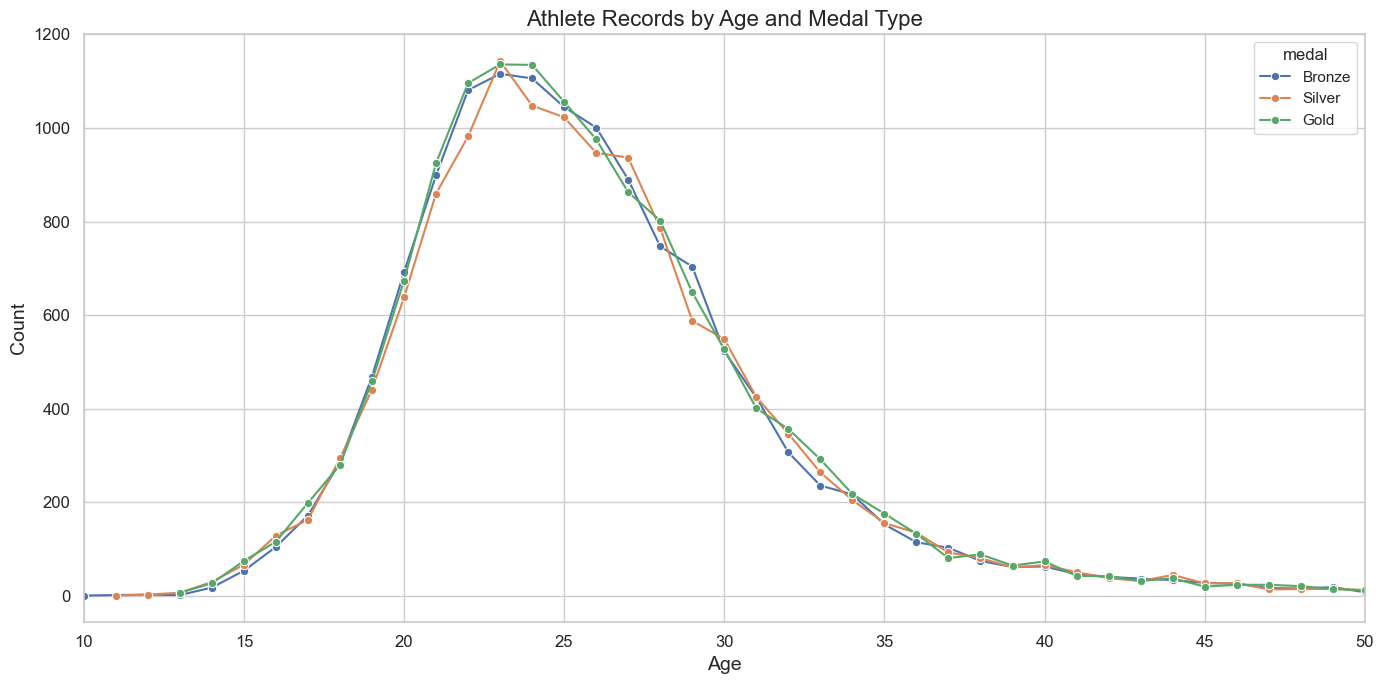

In [135]:
medals_age = olympics.dropna(subset=["age"]).copy()

age_medal = (
    medals_age.groupby(["age", "medal"])
    .size()
    .reset_index(name="count")
)

plt.figure(figsize=(14, 7))
sns.lineplot(data=age_medal, x="age", y="count", hue="medal", marker="o")
plt.title("Athlete Records by Age and Medal Type", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xlim(10, 50)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()